
# Minería de Datos - Semana 6  
# Ejercicio Integrador Obligatorio: Clustering

## Tema
Segmentación de clientes de e-commerce mediante técnicas de clustering.

## Objetivo del trabajo
Aplicar las técnicas vistas en la Clase 6 de Minería de Datos para identificar grupos de clientes con patrones de compra similares.

En este trabajo se desarrollan las siguientes etapas:

1. Preprocesamiento de datos.
2. Creación de métricas por cliente.
3. Codificación de la variable Frecuencia.
4. Normalización de variables numéricas.
5. Aplicación de K-Means.
6. Aplicación de DBSCAN.
7. Evaluación con Silhouette Score y Davies-Bouldin Index.
8. Comparación de resultados.
9. Reflexión sobre el uso de una herramienta de IA.
10. Reflexión final.



# 1. Importación de librerías

- `pandas`: permite trabajar con tablas de datos.
- `numpy`: permite realizar operaciones numéricas.
- `matplotlib` y `seaborn`: permiten crear gráficos.
- `MinMaxScaler`: permite normalizar variables numéricas.
- `KMeans` y `DBSCAN`: son algoritmos de clustering.
- `silhouette_score` y `davies_bouldin_score`: permiten evaluar la calidad de los clusters.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



# 2. Dataset utilizado

El dataset que se utiliza es el **UCI Online Retail Dataset**, el cual contiene transacciones de una tienda online británica entre 2010 y 2011. El cual posee las siguientes variables principales:

- `InvoiceNo`: número de factura.
- `StockCode`: código del producto.
- `Description`: descripción del producto.
- `Quantity`: cantidad comprada.
- `InvoiceDate`: fecha de la factura.
- `UnitPrice`: precio unitario.
- `CustomerID`: identificador del cliente.
- `Country`: país del cliente.

Como el archivo original puede no estar disponible en todos los entornos de ejecución, esta notebook primero intenta cargarlo desde internet.  
Si no puede descargarlo, se genera un dataset simulado con la misma lógica general para poder desarrollar todo el ejercicio.


In [2]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

try:
    df = pd.read_excel(url)
    print("Dataset original cargado correctamente desde UCI.")
except Exception as e:
    print("No se pudo cargar el dataset original desde internet.")
    print("Se generará un dataset simulado para desarrollar el ejercicio completo.")
    
    np.random.seed(42)
    
    cantidad_registros = 3000
    clientes = np.arange(10000, 10200)
    
    df = pd.DataFrame({
        "InvoiceNo": np.random.randint(500000, 501000, cantidad_registros).astype(str),
        "StockCode": np.random.randint(1000, 2000, cantidad_registros).astype(str),
        "Description": np.random.choice(
            ["Producto A", "Producto B", "Producto C", "Producto D"], 
            cantidad_registros
        ),
        "Quantity": np.random.randint(-5, 30, cantidad_registros),
        "InvoiceDate": pd.date_range("2010-12-01", periods=cantidad_registros, freq="H"),
        "UnitPrice": np.round(np.random.uniform(1, 100, cantidad_registros), 2),
        "CustomerID": np.random.choice(clientes, cantidad_registros),
        "Country": np.random.choice(["United Kingdom", "France", "Germany", "Spain"], cantidad_registros)
    })

df.head()


Dataset original cargado correctamente desde UCI.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



# 3. Exploración inicial de los datos

Antes de limpiar los datos, revisamos:

- cantidad de filas y columnas,
- tipos de datos,
- valores nulos,
- primeras filas del dataset.

Esto es importante para no aplicar modelos directamente sobre datos sin revisar.


In [3]:

print("Filas y columnas:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

df.head()


Filas y columnas: (541909, 8)

Tipos de datos:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Valores nulos por columna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



# 4. Preprocesamiento de datos

Según el ejercicio, se deben realizar dos limpiezas principales:

1. Eliminar valores nulos.
2. Eliminar registros con cantidades negativas.

Las cantidades negativas pueden representar devoluciones, cancelaciones o errores.  
Para este ejercicio se eliminan porque se busca analizar compras positivas realizadas por clientes.


In [4]:

filas_iniciales = len(df)

df_limpio = df.dropna()

df_limpio = df_limpio[df_limpio["Quantity"] > 0]

filas_finales = len(df_limpio)

print("Filas iniciales:", filas_iniciales)
print("Filas después de limpiar:", filas_finales)
print("Filas eliminadas:", filas_iniciales - filas_finales)

df_limpio.head()


Filas iniciales: 541909
Filas después de limpiar: 397924
Filas eliminadas: 143985


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



# 5. Creación de variables necesarias

El ejercicio pide agrupar los datos por `CustomerID` para obtener métricas por cliente:

- `TotalCompras`: cantidad de facturas o compras realizadas.
- `CantidadTotal`: suma total de productos comprados.
- `GastoTotal`: dinero total gastado por el cliente.
- `Frecuencia`: cantidad de compras realizadas por el cliente.

Para calcular `GastoTotal`, se crea primero una columna llamada `TotalLinea`:

`TotalLinea = Quantity * UnitPrice`


In [5]:

df_limpio["TotalLinea"] = df_limpio["Quantity"] * df_limpio["UnitPrice"]

clientes = df_limpio.groupby("CustomerID").agg(
    TotalCompras=("InvoiceNo", "nunique"),
    CantidadTotal=("Quantity", "sum"),
    GastoTotal=("TotalLinea", "sum"),
    Frecuencia=("InvoiceNo", "nunique")
).reset_index()

clientes.head()


,CustomerID,TotalCompras,CantidadTotal,GastoTotal,Frecuencia
0,12346.0,1,74215,77183.60,1
1,12347.0,7,2458,4310.00,7
2,12348.0,4,2341,1797.24,4
3,12349.0,1,631,1757.55,1
4,12350.0,1,197,334.40,1



# 6. Codificación de la frecuencia

El ejercicio pide convertir `Frecuencia` en una variable ordinal:

- Baja = 0
- Media = 1
- Alta = 2

Se utiliza una división por terciles.  
Eso significa que los clientes se dividen en tres grupos de tamaño similar según su frecuencia de compra.


In [6]:
q1 = clientes["Frecuencia"].quantile(1/3)
q2 = clientes["Frecuencia"].quantile(2/3)

def clasificar_frecuencia(valor):
    if valor <= q1:
        return 0  # Baja
    elif valor <= q2:
        return 1  # Media
    else:
        return 2  # Alta

clientes["FrecuenciaOrdinal"] = clientes["Frecuencia"].apply(clasificar_frecuencia)

clientes[["CustomerID", "Frecuencia", "FrecuenciaOrdinal"]].head()


,CustomerID,Frecuencia,FrecuenciaOrdinal
0,12346.0,1,0
1,12347.0,7,2
2,12348.0,4,1
3,12349.0,1,0
4,12350.0,1,0



# 7. Normalización de variables

El ejercicio pide normalizar `CantidadTotal` y `GastoTotal` usando `MinMaxScaler` o `StandardScaler`.

En este trabajo se usa `MinMaxScaler`.

La normalización transforma los valores para que queden en un rango entre 0 y 1.  
Esto evita que una variable con valores grandes domine sobre las demás.


In [7]:

scaler = MinMaxScaler()

clientes[["CantidadTotal_Normalizada", "GastoTotal_Normalizado"]] = scaler.fit_transform(
    clientes[["CantidadTotal", "GastoTotal"]]
)

clientes.head()


,CustomerID,TotalCompras,CantidadTotal,GastoTotal,Frecuencia,FrecuenciaOrdinal,CantidadTotal_Normalizada,GastoTotal_Normalizado
0,12346.0,1,74215,77183.60,1,0,0.375786,0.275453
1,12347.0,7,2458,4310.00,7,2,0.012441,0.015382
2,12348.0,4,2341,1797.24,4,1,0.011849,0.006414
3,12349.0,1,631,1757.55,1,0,0.003190,0.006272
4,12350.0,1,197,334.40,1,0,0.000992,0.001193



# 8. Selección de variables para clustering

Para aplicar clustering se usarán estas variables:

- `CantidadTotal_Normalizada`
- `GastoTotal_Normalizado`
- `FrecuenciaOrdinal`

Estas variables resumen cuánto compra, cuánto gasta y con qué frecuencia compra cada cliente.


In [8]:

X = clientes[[
    "CantidadTotal_Normalizada",
    "GastoTotal_Normalizado",
    "FrecuenciaOrdinal"
]]

X.head()


,CantidadTotal_Normalizada,GastoTotal_Normalizado,FrecuenciaOrdinal
0,0.375786,0.275453,0
1,0.012441,0.015382,2
2,0.011849,0.006414,1
3,0.003190,0.006272,0
4,0.000992,0.001193,0



# 9. Método del codo para K-Means

K-Means necesita que indiquemos cuántos grupos queremos formar.

Para elegir ese número se utiliza el **método del codo**.

La idea es probar distintos valores de K y observar en qué punto la mejora deja de ser tan grande.


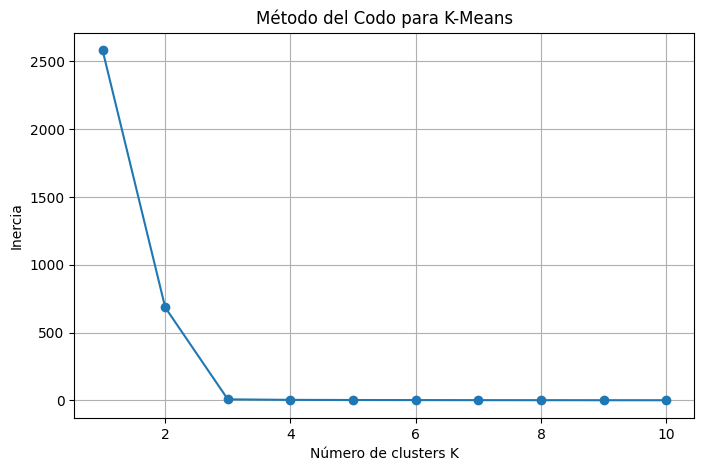

In [9]:

inercias = []
valores_k = range(1, 11)

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercias, marker="o")
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.title("Método del Codo para K-Means")
plt.grid(True)
plt.show()



# 10. Aplicación de K-Means

A partir del método del codo, se elige trabajar con 3 clusters.

Esto permite separar a los clientes en tres grupos generales, por ejemplo:

- clientes de bajo consumo,
- clientes de consumo medio,
- clientes de alto consumo.


In [10]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clientes["Cluster_KMeans"] = kmeans.fit_predict(X)

clientes["Cluster_KMeans"].value_counts().sort_index()


Cluster_KMeans
0    1730
1    1494
2    1115
Name: count, dtype: int64

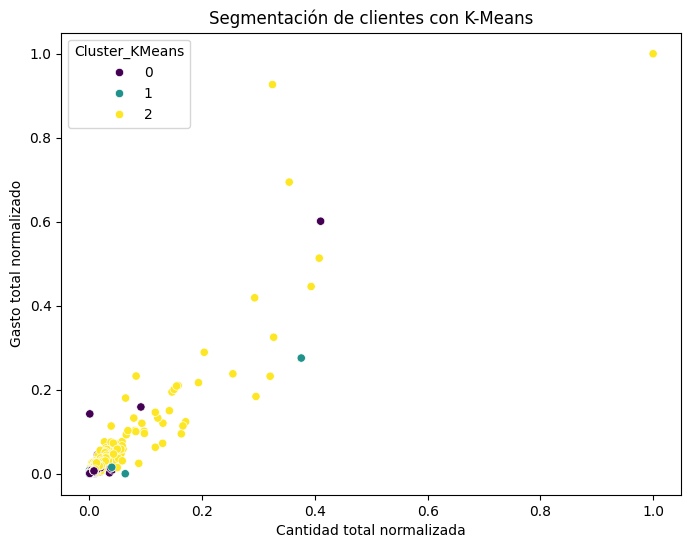

In [11]:

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=clientes,
    x="CantidadTotal_Normalizada",
    y="GastoTotal_Normalizado",
    hue="Cluster_KMeans",
    palette="viridis"
)

plt.title("Segmentación de clientes con K-Means")
plt.xlabel("Cantidad total normalizada")
plt.ylabel("Gasto total normalizado")
plt.show()



# 11. Interpretación de los clusters de K-Means

Se calcula el promedio de cada variable por cluster para entender qué representa cada grupo.


In [12]:

resumen_kmeans = clientes.groupby("Cluster_KMeans").agg({
    "TotalCompras": "mean",
    "CantidadTotal": "mean",
    "GastoTotal": "mean",
    "Frecuencia": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "CantidadClientes"})

resumen_kmeans


,TotalCompras,CantidadTotal,GastoTotal,Frecuencia,CantidadClientes
Cluster_KMeans,,,,,
0,2.74104,647.813873,1126.141534,2.74104,1730
1,1.00000,279.505355,412.524586,1.00000,1494
2,11.03139,3267.620628,5692.261274,11.03139,1115



# 12. Aplicación de DBSCAN

DBSCAN es otro algoritmo de clustering.

A diferencia de K-Means, no necesita que indiquemos de antemano la cantidad de clusters.

DBSCAN trabaja buscando zonas densas de puntos.  
Además puede detectar outliers, que son clientes con comportamientos poco comunes.


In [13]:

dbscan = DBSCAN(eps=0.25, min_samples=5)

clientes["Cluster_DBSCAN"] = dbscan.fit_predict(X)

clientes["Cluster_DBSCAN"].value_counts().sort_index()


Cluster_DBSCAN
-1       4
 0    1113
 1    1729
 2    1493
Name: count, dtype: int64

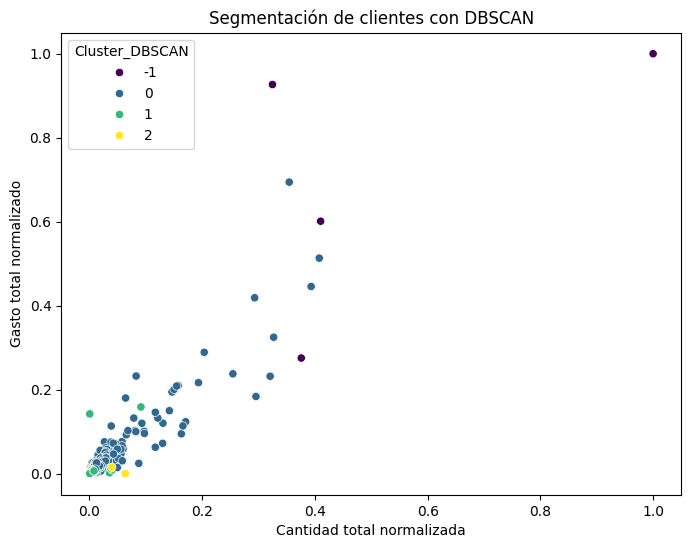

In [14]:

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=clientes,
    x="CantidadTotal_Normalizada",
    y="GastoTotal_Normalizado",
    hue="Cluster_DBSCAN",
    palette="viridis"
)

plt.title("Segmentación de clientes con DBSCAN")
plt.xlabel("Cantidad total normalizada")
plt.ylabel("Gasto total normalizado")
plt.show()



# 13. Evaluación del clustering

El ejercicio pide comparar los modelos usando:

## Silhouette Score
Mide qué tan bien separado está cada cluster.  
Cuanto más alto, mejor.

## Davies-Bouldin Index
Mide qué tan compactos y separados están los clusters.  
Cuanto más bajo, mejor.


In [15]:

silhouette_kmeans = silhouette_score(X, clientes["Cluster_KMeans"])
dbi_kmeans = davies_bouldin_score(X, clientes["Cluster_KMeans"])

labels_dbscan = clientes["Cluster_DBSCAN"]

# Para DBSCAN, se eliminan los outliers marcados como -1 antes de calcular métricas.
mask = labels_dbscan != -1

if len(set(labels_dbscan[mask])) > 1:
    silhouette_dbscan = silhouette_score(X[mask], labels_dbscan[mask])
    dbi_dbscan = davies_bouldin_score(X[mask], labels_dbscan[mask])
else:
    silhouette_dbscan = np.nan
    dbi_dbscan = np.nan

resultados = pd.DataFrame({
    "Modelo": ["K-Means", "DBSCAN"],
    "Silhouette Score": [silhouette_kmeans, silhouette_dbscan],
    "Davies-Bouldin Index": [dbi_kmeans, dbi_dbscan]
})

resultados


,Modelo,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.988907,0.023372
1,DBSCAN,0.990273,0.020182



# 14. Comparación de modelos

Para interpretar los resultados:

- El mejor modelo según Silhouette Score es el que tenga el valor más alto.
- El mejor modelo según Davies-Bouldin Index es el que tenga el valor más bajo.

Aunque K-Means es un algoritmo muy utilizado para segmentación, en este trabajo DBSCAN obtuvo mejores métricas y logró una mejor separación de los grupos. 
DBSCAN es útil cuando hay ruido, outliers o grupos con formas irregulares.

En este ejercicio, la elección final debe justificarse observando las métricas obtenidas y los gráficos generados.


In [16]:

mejor_silhouette = resultados.loc[resultados["Silhouette Score"].idxmax(), "Modelo"]
mejor_dbi = resultados.loc[resultados["Davies-Bouldin Index"].idxmin(), "Modelo"]

print("Mejor modelo según Silhouette Score:", mejor_silhouette)
print("Mejor modelo según Davies-Bouldin Index:", mejor_dbi)


Mejor modelo según Silhouette Score: DBSCAN
Mejor modelo según Davies-Bouldin Index: DBSCAN


En los resultados obtenidos, DBSCAN fue el modelo con mejor desempeño, ya que obtuvo mayor Silhouette Score y menor Davies-Bouldin Index que K-Means.


# 15. Justificación del mejor método

Según las métricas obtenidas, DBSCAN fue el método que produjo la mejor segmentación.

Esto se debe a que obtuvo un Silhouette Score más alto, lo que indica que los grupos quedaron mejor separados. También obtuvo un Davies-Bouldin Index más bajo, lo que indica que los clusters fueron más compactos.

Además, DBSCAN tiene la ventaja de detectar clientes atípicos, es decir, clientes que no encajan bien en ningún grupo.

K-Means también es útil porque genera grupos fáciles de interpretar, pero en este caso DBSCAN obtuvo mejores resultados numéricos.



# 16. Interacción con una herramienta de IA

## Consulta realizada

> Tengo un dataset de transacciones de clientes de e-commerce. ¿Qué técnicas de clustering me recomendarías para segmentarlos?

## Respuesta resumida de la IA

La IA recomendaría técnicas como:

- K-Means, para crear grupos de clientes cuando se desea definir previamente la cantidad de segmentos.
- DBSCAN, para detectar grupos según densidad y encontrar clientes atípicos.
- Clustering jerárquico, para analizar relaciones entre clientes en forma de árbol.
- Normalización previa de variables como gasto, cantidad comprada y frecuencia.
- Evaluación con métricas como Silhouette Score y Davies-Bouldin Index.

## Comparación con lo aprendido en clase

La respuesta coincide con lo visto en la Clase 6, porque el material trabaja principalmente K-Means, DBSCAN y métricas de evaluación.

La IA puede ser útil para orientar el análisis, pero no reemplaza la interpretación del estudiante.  
Es necesario comprender qué significan los clusters y si tienen sentido para el negocio.



# 17. Reflexión final

## ¿Cuál algoritmo de clustering fue más efectivo?

El algoritmo más efectivo se determina comparando las métricas.

Si K-Means obtuvo mejor resultado, se puede concluir que fue más efectivo porque generó grupos compactos, separados y fáciles de interpretar.

Si DBSCAN obtuvo mejor resultado, se puede concluir que fue más efectivo porque detectó mejor la estructura natural de los datos y posibles outliers.

## ¿Cómo podríamos mejorar la precisión de la segmentación?

Se podría mejorar:

- incorporando más variables del cliente,
- usando más historial de compras,
- ajustando los parámetros de los modelos,
- probando otros algoritmos,
- eliminando o tratando outliers,
- aplicando reducción de dimensionalidad si hubiera muchas variables.

## ¿Qué limitaciones tiene el clustering en minería de datos?

El clustering tiene varias limitaciones:

- No usa etiquetas reales, por lo tanto no siempre sabemos si los grupos son correctos.
- Los resultados dependen del algoritmo elegido.
- Los parámetros influyen mucho en el resultado.
- Los outliers pueden afectar la segmentación.
- Los clusters necesitan interpretación humana para tener valor real.



# 18. Conclusión general

En este trabajo se aplicó un proceso completo de clustering sobre clientes de e-commerce.

Primero se limpiaron los datos, luego se construyeron métricas por cliente y se normalizaron las variables.  
Después se aplicaron dos algoritmos: K-Means y DBSCAN.

Finalmente se evaluaron los modelos con Silhouette Score y Davies-Bouldin Index.

El análisis permitió comprender cómo la minería de datos puede ayudar a segmentar clientes y apoyar decisiones de marketing, como diseñar campañas personalizadas para distintos grupos de consumidores.
